In [18]:
# Import data handling and visualization tools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Machine Learning tools for forecasting and measuring accuracy
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Set our graph style
sns.set_theme(style="whitegrid")

In [19]:
file_path = r"C:\Users\nopj2\OneDrive\Desktop\Pranjal_Smart_Meter_Data_Analysis\Daily_Billing_Load Profile.xlsx"

#Load the data
df = pd.read_excel(file_path, sheet_name="Load_profile")

#Formatting
df['READ_DTTM'] = pd.to_datetime(df['READ_DTTM'], dayfirst=True, errors='coerce')

# Filtering Energy Consumption (KWH)
kwh_df = df[df['MEASUREMENT_TYPE_NAME'] == 'UP - Block Load Energy KWH'].copy()

daily_df = kwh_df.set_index('READ_DTTM').resample('D')['READS'].sum().reset_index()
daily_df.rename(columns={'READ_DTTM': 'Date', 'READS': 'Daily_KWH'}, inplace=True)

daily_df = daily_df.dropna()

daily_df.head(10)

,Date,Daily_KWH
0,2025-05-01,12.468
1,2025-05-02,12.690
2,2025-05-03,13.312
3,2025-05-04,13.961
4,2025-05-05,11.737
5,2025-05-06,10.508
6,2025-05-07,11.853
7,2025-05-08,13.965
8,2025-05-09,11.094
9,2025-05-10,13.813


In [20]:
#Feature Engineering
daily_df['DayOfWeek'] = daily_df['Date'].dt.dayofweek
daily_df['DayOfMonth'] = daily_df['Date'].dt.day
daily_df['Month'] = daily_df['Date'].dt.month

#Binary feature for the Weekend(Saturday=5, Sunday=6)
daily_df['Is_Weekend'] = daily_df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

daily_df.head(10)

,Date,Daily_KWH,DayOfWeek,DayOfMonth,Month,Is_Weekend
0,2025-05-01,12.468,3,1,5,0
1,2025-05-02,12.690,4,2,5,0
2,2025-05-03,13.312,5,3,5,1
3,2025-05-04,13.961,6,4,5,1
4,2025-05-05,11.737,0,5,5,0
5,2025-05-06,10.508,1,6,5,0
6,2025-05-07,11.853,2,7,5,0
7,2025-05-08,13.965,3,8,5,0
8,2025-05-09,11.094,4,9,5,0
9,2025-05-10,13.813,5,10,5,1


In [21]:
#Data Splitting

features = ['DayOfWeek', 'DayOfMonth', 'Month', 'Is_Weekend']
X = daily_df[features]
y = daily_df['Daily_KWH']

split_point = int(len(daily_df) * 0.8)

X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

print(f"-> Training on {len(X_train)} historical days.")
print(f"-> Testing predictions on {len(X_test)} unseen future days.")

-> Training on 93 historical days.
-> Testing predictions on 24 unseen future days.


In [ ]:

#Model Training and Prediction
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
predictions

array([16.7279 , 17.32508, 16.88877, 15.71672, 13.55169, 12.92947,
       13.79131, 13.65124, 13.03644, 14.68395, 15.09889, 14.79534,
       14.45685, 14.29776, 15.32913, 14.73864, 16.35861, 20.07309,
       21.00947, 21.40839, 21.78893, 20.36826, 22.05341, 22.35808])

-> Mean Absolute Error (MAE): 3.59 KWH
-> Root Mean Squared Error (RMSE): 5.69 KWH


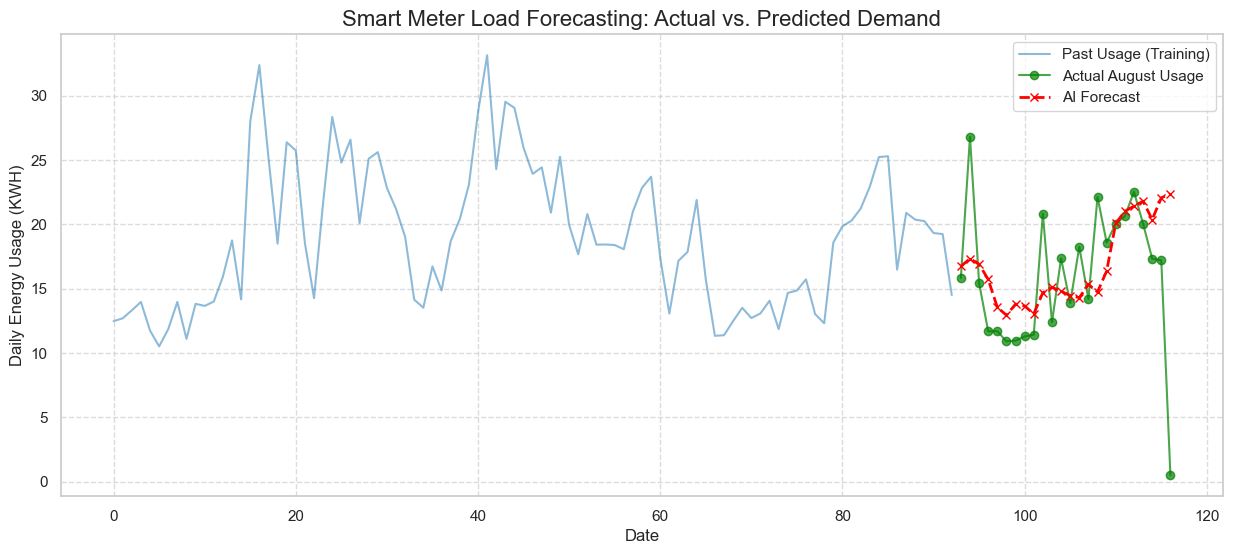

In [23]:
#Evalualtion
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"-> Mean Absolute Error (MAE): {mae:.2f} KWH")
print(f"-> Root Mean Squared Error (RMSE): {rmse:.2f} KWH")

#Visualization of Actual vs Predicted
plt.figure(figsize=(15, 6))


plt.plot(y_train.index, y_train, label='Past Usage (Training)', color='#1f77b4', alpha=0.5)
plt.plot(y_test.index, y_test, label='Actual August Usage', color='green', marker='o', alpha=0.7)

plt.plot(y_test.index, predictions, label='AI Forecast', color='red', linestyle='--', marker='x', linewidth=2)

# Format the graph
plt.title('Smart Meter Load Forecasting: Actual vs. Predicted Demand', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Energy Usage (KWH)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Display the result
plt.show()

# Final Report: Load Forecasting & Demand Prediction Model

## 1. Overview

The objective of this module was to develop a predictive model capable of forecasting daily energy consumption (KWH). This model leverages historical load profile data to enable better grid operational planning and resource management.

## 2. Methodology

* **Data Aggregation**: The raw 15-minute load interval data was resampled to calculate total daily energy consumption (Daily KWH).


* **Feature Engineering**: To enable the model to identify temporal patterns, the following features were engineered from the timestamp data:


* **Day of the Week**: Captured weekly cyclical behavior.
* **Day of the Month**: Accounted for potential monthly billing cycle impacts.
* **Month**: Captured seasonal energy usage variations.
* **Is_Weekend**: A binary flag identifying weekend vs. weekday consumption differences.




* **Model Selection**: A Random Forest Regressor (n_estimators=100) was utilized to capture non-linear relationships between time features and energy demand.


* **Model Validation**: The dataset was split chronologically to respect the time-series nature of the data, training on the first 80% of the timeline and testing on the final 20% (August data).



## 3. Performance Metrics

The model's performance on the unseen August test set was evaluated using the following error metrics:

* **Mean Absolute Error (MAE)**: 3.59 KWH 


* **Root Mean Squared Error (RMSE)**: 5.69 KWH 



**Interpretation**: The model successfully captures the general trend of energy consumption. The error margin suggests that while the model follows the overall demand patterns, there is room for improvement in predicting high-volatility peak usage days.

## 4. Observations & Insights

* **Trend Capture**: The visual comparison between the "Actual August Usage" and "AI Forecast" confirms that the model effectively tracks the directional movement of energy demand.


* **Utility Application**: This model serves as a foundation for predictive grid management. By identifying upcoming demand patterns, the utility can optimize load distribution and reduce infrastructure stress.



## 5. Recommendations

* **Incorporate External Factors**: To improve the MAE and RMSE, it is recommended to integrate external environmental data, such as daily temperature or humidity, as these are primary drivers for heavy appliance usage (e.g., air conditioning).


* **Advanced Architectures**: For future iterations, exploring time-series specific models such as XGBoost, LSTM Neural Networks, or Facebook Prophet may yield higher accuracy in handling seasonal volatility.


* **Continuous Monitoring**: Integrating this forecasting model into a real-time dashboard would allow operators to compare actual vs. predicted demand on a daily basis, facilitating immediate corrective actions.